In [1]:
# imports

import torch
import torch.nn as nn
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
from tqdm import tqdm
from models import Model3
from helper import DeepfakeDataset

SEED = 38

torch.manual_seed(SEED)

Training Dataset
torch.Size([16, 3, 224, 224])
torch.Size([16, 1, 224, 224])
tensor(1.)


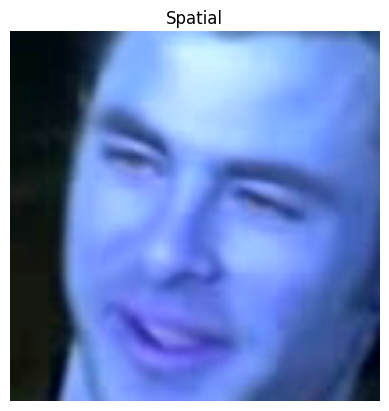

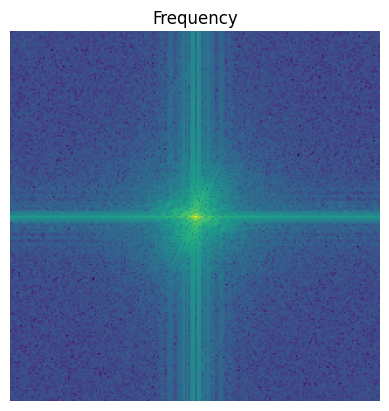

In [2]:
train_dataset = DeepfakeDataset("preprocessed/train", mode="train")

sample = train_dataset[0]

print("Training Dataset")
print(sample["spatial"].shape)
print(sample["frequency"].shape)
print(sample["label"])

plt.imshow(sample["spatial"][0].permute(1, 2, 0))
plt.title("Spatial")
plt.axis("off")
plt.show()

plt.imshow(sample["frequency"][0][0])
plt.title("Frequency")
plt.axis("off")
plt.show()

In [3]:
print("Validation Dataset")
val_dataset = DeepfakeDataset("preprocessed/val", mode="val")
sample = val_dataset[0]
print(sample["spatial"].shape)
print(sample["frequency"].shape)
print(sample["label"])

Validation Dataset
torch.Size([16, 3, 224, 224])
torch.Size([16, 1, 224, 224])
tensor(1.)


In [4]:
train_loader = DataLoader(train_dataset, batch_size=4, shuffle=True)
val_loader   = DataLoader(val_dataset, batch_size=4, shuffle=False)

In [5]:
model = Model3()
criterion = nn.BCEWithLogitsLoss(pos_weight = torch.tensor([0.7]))
optimizer = torch.optim.AdamW(model.parameters(), lr=3e-5, weight_decay=1e-4)

In [6]:
def train_step(model, loader, optimizer, criterion):
    model.train()

    total_loss = 0
    total_acc = 0

    pbar = tqdm(loader)
    for batch in pbar:
        spatial = batch["spatial"].float()
        frequency = batch["frequency"].float()
        labels = batch["label"].unsqueeze(1).float()
    
        out, frame_preds, weights = model(spatial, frequency)
        
        video_loss = criterion(out, labels)
        frame_labels = labels.unsqueeze(1).expand_as(frame_preds)
        frame_loss = criterion(frame_preds, frame_labels)

        loss = video_loss + (0.3 * frame_loss)

        probs = torch.sigmoid(out)
        preds = (probs > 0.5).float()

        acc = (preds == labels).float().mean()
    
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
    
        total_loss += loss.item()
        total_acc += acc.item()

    return total_loss/len(loader), total_acc / len(loader)

class Early_Stopping:
    def __init__(self, patience=2):
        self.patience = patience
        self.best_loss = float("inf")
        self.counter = 0

    def step(self, model, val_loss):
        if val_loss < self.best_loss:
            self.best_loss = val_loss
            torch.save(model.state_dict(), "Model3.pth")
            self.counter = 0
            return False
        else:
            self.counter += 1
            if self.counter >= self.patience:
                return True
            return False

def validate_step(model, loader, criterion):
    model.eval()
    total_loss = 0
    total_acc = 0
    pbar = tqdm(loader)

    with torch.no_grad():
        for batch in pbar:
            spatial = batch["spatial"]
            frequency = batch["frequency"]
            labels = batch["label"].unsqueeze(1)

            out, frame_preds, weights = model(spatial, frequency)

            video_loss = criterion(out, labels)
            frame_labels = labels.unsqueeze(1).expand_as(frame_preds)
            frame_loss = criterion(frame_preds, frame_labels)
            loss = video_loss + (0.3 * frame_loss)
            
            probs = torch.sigmoid(out)
            preds = (probs > 0.5).float()
            acc = (preds == labels).float().mean()

            total_loss += loss.item()
            total_acc += acc.item()

    return total_loss / len(loader), total_acc / len(loader)

def train(model, tr_loader, val_loader, optimizer, criterion, epochs):
    early_stopper = Early_Stopping()

    print("Training Starts")
    
    for epoch in range(epochs):
        print(f"Epoch {epoch}:-")
        train_loss, train_acc = train_step(model, tr_loader, optimizer, criterion)
        val_loss, val_acc = validate_step(model, val_loader, criterion)
        print(f"\nTrain loss = {train_loss} Train Acc = {train_acc}\nVal Loss = {val_loss} Val Acc = {val_acc}\n\n")

        if early_stopper.step(model, val_loss):
            print("----Early Stopping----")
            break
    
    print("Training Done, Best Model Loss: ", early_stopper.best_loss)


train(model, train_loader, val_loader, optimizer, criterion, 20)

Training Starts
Epoch 0:-


100%|██████████| 120/120 [03:22<00:00,  1.69s/it]



Train loss = 0.6596761851114185 Train Acc = 0.6729390681003584
Val Loss = 0.4797505388657252 Val Acc = 0.7916666666666666


Epoch 1:-


100%|██████████| 120/120 [03:33<00:00,  1.78s/it]



Train loss = 0.5267337427130737 Train Acc = 0.78584229390681
Val Loss = 0.3585753720253706 Val Acc = 0.9020833333333333


Epoch 2:-


...


Train loss = 0.21558794661635353 Train Acc = 0.9511648745519713
Val Loss = 0.261335295640553 Val Acc = 0.91875


Epoch 10:-


100%|██████████| 120/120 [04:32<00:00,  2.27s/it]



Train loss = 0.22248227201989687 Train Acc = 0.9484767025089605
Val Loss = 0.2663499333973353 Val Acc = 0.9104166666666667


Epoch 11:-


100%|██████████| 120/120 [04:18<00:00,  2.15s/it]


Train loss = 0.19939244615321305 Train Acc = 0.9663978494623656
Val Loss = 0.26306303484986227 Val Acc = 0.9208333333333333


----Early Stopping----
Training Done, Best Model Loss:  0.261335295640553
